# Cân bằng dữ liệu - DsPCBSD+ (YOLOv8)

**Chiến lược:** Sử dụng các kỹ thuật augmentation nâng cao giữ nguyên chi tiết lỗi nhỏ:
1. **Copy-Paste Instance Augmentation** – sao chép bbox lỗi từ minority class, dán lên ảnh PCB khác
2. **Frequency Domain Augmentation (FDA)** – chuyển style/texture giữa các ảnh PCB
3. **CLAHE + Color Jitter nhẹ** – tăng cường độ tương phản không làm mờ chi tiết
4. **MixUp cho Object Detection** – blend 2 ảnh + merge label tương ứng
5. **GridShuffle Patch Swap** – hoán đổi patch vùng non-defect giữ nguyên defect

**Classes:** `open`, `short`, `mousebite`, `spur`, `copper`, `missing_hole`

**Target:** cân bằng về lớp `short` (ít nhất: 654 train) → upsampling minority classes.

## 1. Import & Config

In [1]:
import os
import cv2
import numpy as np
import yaml
import random
import shutil
from pathlib import Path
from tqdm import tqdm
from copy import deepcopy
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import albumentations as A
from skimage import exposure

random.seed(42)
np.random.seed(42)

# ─── Đường dẫn ───
ROOT       = Path("../data/processed/DsPCBSD+")
OUTPUT_DIR = Path("../data/processed/DsPCBSD+_balanced")

SPLITS = ["train", "valid", "test"]

CLASS_NAMES = ["open", "short", "mousebite", "spur", "copper", "missing_hole"]
NUM_CLASSES = len(CLASS_NAMES)

def resolve_split_dirs(root: Path, split: str):
    """
    Hỗ trợ 2 layout phổ biến của YOLO:
    1) root/train/images + root/train/labels
    2) root/images/train + root/labels/train
    Ưu tiên layout đang tồn tại trên disk.
    """
    split_first_img = root / split / "images"
    split_first_lbl = root / split / "labels"
    yolo_img = root / "images" / split
    yolo_lbl = root / "labels" / split

    if split_first_img.exists() or split_first_lbl.exists():
        return split_first_img, split_first_lbl
    if yolo_img.exists() or yolo_lbl.exists():
        return yolo_img, yolo_lbl

    # Mặc định theo layout split-first vì đó là cấu trúc đang mô tả trong bài toán
    return split_first_img, split_first_lbl

# ─── Mục tiêu số lượng bounding box mỗi class trong tập TRAIN ───
# Đặt bằng ~80% của class nhiều nhất (spur=3126) để cân bằng không quá cứng
TARGET_PER_CLASS = 2500

print(f"ROOT       : {ROOT.resolve()}")
print(f"OUTPUT_DIR : {OUTPUT_DIR.resolve()}")
print(f"Target BBox/class: {TARGET_PER_CLASS}")

ROOT       : D:\pcb-defect-detection\data\processed\DsPCBSD+
OUTPUT_DIR : D:\pcb-defect-detection\data\processed\DsPCBSD+_balanced
Target BBox/class: 2500


## 2. Phân tích phân bố ban đầu

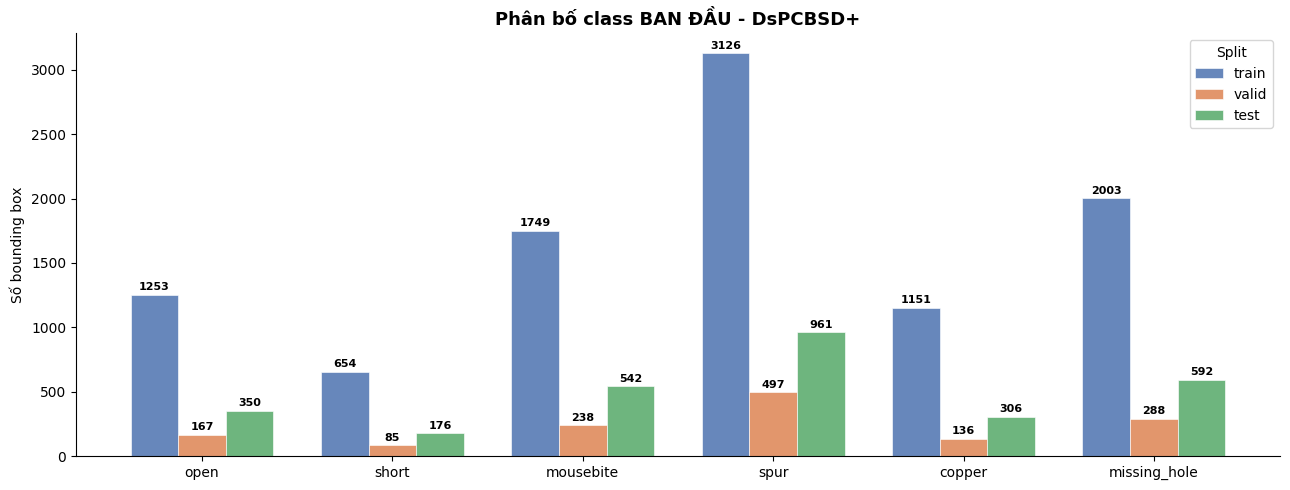

In [2]:
def count_class_distribution(root: Path, splits=None):
    """Đếm số bounding box mỗi class trên từng split."""
    if splits is None:
        splits = SPLITS
    stats = {split: defaultdict(int) for split in splits}

    for split in splits:
        _, label_dir = resolve_split_dirs(root, split)
        if not label_dir.exists():
            print(f"[WARN] Không tìm thấy: {label_dir}")
            continue
        for lf in label_dir.glob("*.txt"):
            with open(lf) as f:
                for line in f:
                    line = line.strip()
                    if line:
                        cls_id = int(line.split()[0])
                        stats[split][cls_id] += 1
    return stats

def plot_distribution(stats, title="Phân bố class"):
    splits = list(stats.keys())
    x = np.arange(NUM_CLASSES)
    width = 0.25
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, split in enumerate(splits):
        vals = [stats[split].get(c, 0) for c in range(NUM_CLASSES)]
        bars = ax.bar(x + i * width - width, vals, width, label=split,
                      color=colors[i], alpha=0.85, edgecolor="white", linewidth=0.5)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                        str(v), ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylabel("Số bounding box")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(title="Split")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

original_stats = count_class_distribution(ROOT)
plot_distribution(original_stats, title="Phân bố class BAN ĐẦU - DsPCBSD+")

## 3. Utility: đọc / ghi YOLO labels

In [3]:
def read_labels(label_path: Path):
    """Trả về list of [class_id, cx, cy, w, h] (normalized)."""
    boxes = []
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    boxes.append([int(parts[0])] + [float(p) for p in parts[1:]])
    return boxes

def write_labels(label_path: Path, boxes):
    label_path.parent.mkdir(parents=True, exist_ok=True)
    with open(label_path, "w") as f:
        for b in boxes:
            f.write(f"{int(b[0])} {b[1]:.6f} {b[2]:.6f} {b[3]:.6f} {b[4]:.6f}\n")

def yolo_to_pixel(box, W, H):
    """[cls, cx, cy, w, h] → [cls, x1, y1, x2, y2] (pixel)."""
    cls, cx, cy, bw, bh = box
    x1 = int((cx - bw / 2) * W)
    y1 = int((cy - bh / 2) * H)
    x2 = int((cx + bw / 2) * W)
    y2 = int((cy + bh / 2) * H)
    return [cls, max(0, x1), max(0, y1), min(W, x2), min(H, y2)]

def pixel_to_yolo(box, W, H):
    """[cls, x1, y1, x2, y2] (pixel) → [cls, cx, cy, w, h] (normalized)."""
    cls, x1, y1, x2, y2 = box
    cx = (x1 + x2) / 2 / W
    cy = (y1 + y2) / 2 / H
    bw = (x2 - x1) / W
    bh = (y2 - y1) / H
    return [cls, cx, cy, bw, bh]

def load_sample(img_path: Path, lbl_path: Path):
    img = cv2.imread(str(img_path))
    boxes = read_labels(lbl_path)
    return img, boxes

def get_pairs(root: Path, split: str):
    """Trả về list of (img_path, lbl_path) cho split."""
    img_dir, lbl_dir = resolve_split_dirs(root, split)
    pairs = []
    for img_path in sorted(img_dir.glob("*.*")):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]:
            continue
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        pairs.append((img_path, lbl_path))
    return pairs

print("Utility functions loaded")

Utility functions loaded


## 4. Kỹ thuật augmentation nâng cao

### 4.1 Copy-Paste Instance Augmentation
> Cắt vùng bbox chứa lỗi từ một ảnh nguồn, dán (với Poisson blending hoặc alpha feathering) lên ảnh đích — giữ nguyên 100% chi tiết lỗi nhỏ.

In [4]:
def feather_mask(h, w, margin=3):
    """Tạo mask mờ viền để blend mượt hơn."""
    mask = np.ones((h, w), dtype=np.float32)
    m = min(margin, h // 4, w // 4)
    if m > 0:
        for i in range(m):
            alpha = (i + 1) / (m + 1)
            mask[i, :]  *= alpha
            mask[-i-1, :] *= alpha
            mask[:, i]  *= alpha
            mask[:, -i-1] *= alpha
    return mask[..., None]   # (H, W, 1)

def copy_paste_instance(
    dst_img: np.ndarray,
    dst_boxes: list,
    src_img: np.ndarray,
    src_boxes: list,
    target_cls: int,
    max_paste: int = 3,
    iou_thresh: float = 0.15,
):
    """
    Dán tối đa `max_paste` instance của `target_cls` từ src sang dst.
    Trả về (new_img, new_boxes).
    """
    H, W = dst_img.shape[:2]
    new_img = dst_img.copy()
    new_boxes = deepcopy(dst_boxes)

    # Lọc instance của target_cls trong src
    src_instances = [
        yolo_to_pixel(b, src_img.shape[1], src_img.shape[0])
        for b in src_boxes if b[0] == target_cls
    ]
    if not src_instances:
        return new_img, new_boxes

    random.shuffle(src_instances)
    pasted = 0

    for inst in src_instances:
        if pasted >= max_paste:
            break
        _, x1s, y1s, x2s, y2s = inst
        bw, bh = x2s - x1s, y2s - y1s
        if bw < 2 or bh < 2:
            continue

        patch = src_img[y1s:y2s, x1s:x2s]
        if patch.size == 0:
            continue

        # Chọn vị trí ngẫu nhiên trên dst (tránh ra ngoài biên)
        if W - bw <= 0 or H - bh <= 0:
            continue
        px1 = random.randint(0, W - bw)
        py1 = random.randint(0, H - bh)
        px2, py2 = px1 + bw, py1 + bh

        # Kiểm tra IoU với box đã có
        overlap = False
        for eb in new_boxes:
            ex1, ey1, ex2, ey2 = [
                int((eb[1] - eb[3]/2) * W),
                int((eb[2] - eb[4]/2) * H),
                int((eb[1] + eb[3]/2) * W),
                int((eb[2] + eb[4]/2) * H),
            ]
            ix1, iy1 = max(px1, ex1), max(py1, ey1)
            ix2, iy2 = min(px2, ex2), min(py2, ey2)
            inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
            union = bw * bh + (ex2-ex1)*(ey2-ey1) - inter
            if union > 0 and inter / union > iou_thresh:
                overlap = True
                break
        if overlap:
            continue

        # Alpha feathering paste
        fmask = feather_mask(bh, bw, margin=max(2, min(bw, bh) // 8))
        roi   = new_img[py1:py2, px1:px2].astype(np.float32)
        blended = patch.astype(np.float32) * fmask + roi * (1 - fmask)
        new_img[py1:py2, px1:px2] = blended.astype(np.uint8)

        new_box = pixel_to_yolo([target_cls, px1, py1, px2, py2], W, H)
        new_boxes.append(new_box)
        pasted += 1

    return new_img, new_boxes

print("Copy-Paste module loaded")

Copy-Paste module loaded


### 4.2 Frequency Domain Augmentation (FDA)
> Chuyển "kiểu" texture của ảnh PCB nguồn sang ảnh đích bằng cách hoán đổi thành phần tần số thấp trong không gian Fourier — giữ nguyên cấu trúc lỗi (tần số cao).

In [5]:
def fda_transfer(src_img: np.ndarray, tgt_img: np.ndarray, beta: float = 0.01) -> np.ndarray:
    """
    Frequency Domain Adaptation:
    Thay thế vùng tần số thấp (β) của src bằng của tgt.
    β nhỏ (0.005–0.02) → chỉ đổi màu sắc/ánh sáng tổng thể, giữ nguyên chi tiết.
    """
    assert src_img.shape == tgt_img.shape, "FDA cần 2 ảnh cùng kích thước"
    H, W = src_img.shape[:2]

    def _fda_channel(s, t):
        s_f = np.fft.fft2(s)
        t_f = np.fft.fft2(t)
        s_amp, s_pha = np.abs(s_f), np.angle(s_f)
        t_amp = np.abs(t_f)

        # Vùng tần số thấp (trung tâm sau fftshift)
        h_beta = int(np.floor(H * beta))
        w_beta = int(np.floor(W * beta))
        h_beta = max(1, h_beta)
        w_beta = max(1, w_beta)

        s_amp_shift = np.fft.fftshift(s_amp)
        t_amp_shift = np.fft.fftshift(t_amp)

        cy, cx = H // 2, W // 2
        s_amp_shift[
            cy - h_beta: cy + h_beta,
            cx - w_beta: cx + w_beta
        ] = t_amp_shift[
            cy - h_beta: cy + h_beta,
            cx - w_beta: cx + w_beta
        ]

        new_amp = np.fft.ifftshift(s_amp_shift)
        new_f   = new_amp * np.exp(1j * s_pha)
        result  = np.real(np.fft.ifft2(new_f))
        return np.clip(result, 0, 255).astype(np.uint8)

    channels = []
    for c in range(src_img.shape[2]):
        channels.append(_fda_channel(
            src_img[:, :, c].astype(np.float64),
            tgt_img[:, :, c].astype(np.float64)
        ))
    return np.stack(channels, axis=2)

print("FDA module loaded")

FDA module loaded


### 4.3 MixUp cho Object Detection

In [6]:
def mixup_detection(
    img1: np.ndarray, boxes1: list,
    img2: np.ndarray, boxes2: list,
    alpha: float = 0.4,
):
    """
    MixUp: blend 2 ảnh + gộp toàn bộ nhãn.
    Dùng alpha nhỏ (0.3–0.5) để ảnh không quá mờ.
    """
    lam = np.random.beta(alpha, alpha)
    lam = max(0.3, min(0.7, lam))   # clamp để tránh quá lệch

    H1, W1 = img1.shape[:2]
    H2, W2 = img2.shape[:2]

    # Resize img2 về kích thước img1 nếu khác
    if (H1, W1) != (H2, W2):
        img2 = cv2.resize(img2, (W1, H1))

    mixed_img = (lam * img1.astype(np.float32) +
                 (1 - lam) * img2.astype(np.float32)).astype(np.uint8)
    mixed_boxes = deepcopy(boxes1) + deepcopy(boxes2)
    return mixed_img, mixed_boxes

print("MixUp module loaded")

MixUp module loaded


### 4.4 CLAHE + Advanced Color Jitter (không làm mờ lỗi)

In [7]:
# Albumentations pipeline an toàn cho defect nhỏ
# KHÔNG dùng: Blur, RandomCrop, Rotate > 15°, ShiftScaleRotate scale lớn
SAFE_AUG = A.Compose(
    [
        # ── Tăng tương phản cục bộ (rất tốt cho lỗi nhỏ) ──
        A.CLAHE(clip_limit=(1.0, 4.0), tile_grid_size=(4, 4), p=0.6),

        # ── Color jitter nhẹ ──
        A.HueSaturationValue(
            hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.5
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.12, contrast_limit=0.15, p=0.6
        ),

        # ── Nhiễu sensor (giả lập camera thực tế) ──
        A.GaussNoise(std_range=(0.01, 0.05), p=0.4),

        # ── Chất lượng ảnh (giả lập JPEG compression artifact khác nhau) ─
        A.ImageCompression(quality_range=(80, 99), p=0.3),

        # ── Gamma correction nhẹ ──
        A.RandomGamma(gamma_limit=(85, 115), p=0.4),

        # ── Channel shuffle (chỉ khi ảnh màu) ──
        A.ChannelShuffle(p=0.1),

        # ── Xoay nhẹ — PCB thường đối xứng 90° ──
        A.RandomRotate90(p=0.5),

        # ── Flip không gian ──
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.5,   # giữ bbox nếu còn ≥50% diện tích sau crop
        clip=True,
    ),
)

def apply_safe_aug(img: np.ndarray, boxes: list):
    """Áp dụng SAFE_AUG lên ảnh + label YOLO."""
    if not boxes:
        result = SAFE_AUG(image=img, bboxes=[], class_labels=[])
        return result["image"], []

    bboxes       = [[b[1], b[2], b[3], b[4]] for b in boxes]
    class_labels = [b[0] for b in boxes]

    result = SAFE_AUG(image=img, bboxes=bboxes, class_labels=class_labels)

    new_boxes = [
        [cls] + list(bb)
        for cls, bb in zip(result["class_labels"], result["bboxes"])
    ]
    return result["image"], new_boxes

print("Safe Augmentation pipeline loaded")

Safe Augmentation pipeline loaded


### 4.5 GridShuffle Patch Swap (vùng non-defect)
> Chia ảnh thành lưới patch, hoán đổi ngẫu nhiên các patch KHÔNG chứa bounding box — giữ nguyên vùng lỗi.

In [8]:
def grid_shuffle_nondefect(
    img: np.ndarray,
    boxes: list,
    grid_size: int = 4,
    swap_prob: float = 0.3,
):
    """
    Chia ảnh thành grid_size x grid_size ô.
    Các ô KHÔNG giao với bất kỳ bbox nào → swap ngẫu nhiên với nhau.
    Boxes giữ nguyên (không đổi label).
    """
    H, W = img.shape[:2]
    new_img = img.copy()
    ph, pw  = H // grid_size, W // grid_size

    if ph < 8 or pw < 8:
        return new_img, boxes   # ảnh quá nhỏ, bỏ qua

    # Đánh dấu ô chứa bbox
    def cell_has_box(ri, ci):
        cy1, cy2 = ri * ph, (ri + 1) * ph
        cx1, cx2 = ci * pw, (ci + 1) * pw
        for b in boxes:
            bx1 = int((b[1] - b[3]/2) * W)
            by1 = int((b[2] - b[4]/2) * H)
            bx2 = int((b[1] + b[3]/2) * W)
            by2 = int((b[2] + b[4]/2) * H)
            if bx2 > cx1 and bx1 < cx2 and by2 > cy1 and by1 < cy2:
                return True
        return False

    free_cells = [
        (r, c)
        for r in range(grid_size)
        for c in range(grid_size)
        if not cell_has_box(r, c)
    ]

    random.shuffle(free_cells)
    # Hoán đổi từng cặp
    for i in range(0, len(free_cells) - 1, 2):
        if random.random() > swap_prob:
            continue
        r1, c1 = free_cells[i]
        r2, c2 = free_cells[i + 1]
        patch1 = img[r1*ph:(r1+1)*ph, c1*pw:(c1+1)*pw].copy()
        patch2 = img[r2*ph:(r2+1)*ph, c2*pw:(c2+1)*pw].copy()
        new_img[r1*ph:(r1+1)*ph, c1*pw:(c1+1)*pw] = patch2
        new_img[r2*ph:(r2+1)*ph, c2*pw:(c2+1)*pw] = patch1

    return new_img, deepcopy(boxes)

print("GridShuffle module loaded")

GridShuffle module loaded


## 5. Build index: ảnh theo class

In [9]:
def build_class_index(root: Path, split: str):
    """
    Trả về:
    - pairs: list (img_path, lbl_path)
    - class2pairs: dict cls_id → list of pair indices có chứa cls đó
    """
    pairs = get_pairs(root, split)
    class2pairs = defaultdict(list)

    for idx, (img_p, lbl_p) in enumerate(pairs):
        boxes = read_labels(lbl_p)
        seen  = set(b[0] for b in boxes)
        for cls_id in seen:
            class2pairs[cls_id].append(idx)

    return pairs, class2pairs

train_pairs, train_c2p = build_class_index(ROOT, "train")
print(f"Train: {len(train_pairs)} ảnh")
for c, name in enumerate(CLASS_NAMES):
    print(f"  Class {c} ({name}): {len(train_c2p.get(c, []))} ảnh chứa class này")

Train: 5089 ảnh
  Class 0 (open): 1007 ảnh chứa class này
  Class 1 (short): 418 ảnh chứa class này
  Class 2 (mousebite): 1308 ảnh chứa class này
  Class 3 (spur): 1516 ảnh chứa class này
  Class 4 (copper): 946 ảnh chứa class này
  Class 5 (missing_hole): 904 ảnh chứa class này


## 6. Pipeline sinh ảnh augmented

Chiến lược:
- Mỗi class **thiếu** (count < TARGET) → sinh thêm ảnh bằng cách kết hợp các kỹ thuật trên.
- Chọn kỹ thuật xác suất: 40% Copy-Paste, 25% FDA+SafeAug, 20% MixUp, 15% GridShuffle+SafeAug

In [10]:
def generate_augmented_sample(
    pairs, class2pairs,
    target_cls: int,
    technique: str,
):
    """
    Sinh 1 ảnh augmented tập trung vào target_cls.
    Trả về (aug_img, aug_boxes) hoặc None nếu thất bại.
    """
    cls_indices = class2pairs.get(target_cls, [])
    if not cls_indices:
        return None

    # ── Ảnh nguồn (chứa target_cls) ──
    src_idx = random.choice(cls_indices)
    src_img, src_boxes = load_sample(*pairs[src_idx])
    if src_img is None:
        return None

    if technique == "copy_paste":
        # Chọn ảnh đích ngẫu nhiên (bất kỳ class)
        dst_idx = random.choice(range(len(pairs)))
        dst_img, dst_boxes = load_sample(*pairs[dst_idx])
        if dst_img is None:
            return None

        # Resize src về cùng kích thước dst nếu cần
        H, W = dst_img.shape[:2]
        if src_img.shape[:2] != dst_img.shape[:2]:
            scale = min(W / src_img.shape[1], H / src_img.shape[0])
            src_img = cv2.resize(src_img,
                                 (int(src_img.shape[1]*scale), int(src_img.shape[0]*scale)))

        aug_img, aug_boxes = copy_paste_instance(
            dst_img, dst_boxes, src_img, src_boxes,
            target_cls=target_cls, max_paste=random.randint(1, 4)
        )
        aug_img, aug_boxes = apply_safe_aug(aug_img, aug_boxes)

    elif technique == "fda":
        # Chọn ảnh style ngẫu nhiên (khác với src)
        style_idx = random.choice(range(len(pairs)))
        style_img, _ = load_sample(*pairs[style_idx])
        if style_img is None:
            return None

        H, W = src_img.shape[:2]
        style_img = cv2.resize(style_img, (W, H))

        beta = random.uniform(0.005, 0.02)
        aug_img = fda_transfer(src_img, style_img, beta=beta)
        aug_img, aug_boxes = apply_safe_aug(aug_img, src_boxes)

    elif technique == "mixup":
        # Chọn cặp ảnh khác cũng chứa target_cls (ưu tiên)
        other_idx = random.choice(cls_indices)
        other_img, other_boxes = load_sample(*pairs[other_idx])
        if other_img is None:
            return None

        aug_img, aug_boxes = mixup_detection(
            src_img, src_boxes, other_img, other_boxes,
            alpha=random.uniform(0.3, 0.5)
        )
        aug_img, aug_boxes = apply_safe_aug(aug_img, aug_boxes)

    elif technique == "grid_shuffle":
        aug_img, aug_boxes = grid_shuffle_nondefect(
            src_img, src_boxes,
            grid_size=random.choice([3, 4, 5]),
            swap_prob=0.35
        )
        aug_img, aug_boxes = apply_safe_aug(aug_img, aug_boxes)

    else:
        raise ValueError(f"Unknown technique: {technique}")

    # Đảm bảo kết quả còn box của target_cls
    has_target = any(b[0] == target_cls for b in aug_boxes)
    if not has_target:
        return None

    return aug_img, aug_boxes

TECHNIQUES = ["copy_paste", "fda", "mixup", "grid_shuffle"]
TECHNIQUE_WEIGHTS = [0.40, 0.25, 0.20, 0.15]

def pick_technique():
    return random.choices(TECHNIQUES, weights=TECHNIQUE_WEIGHTS, k=1)[0]

print("Generator pipeline ready")

Generator pipeline ready


## 7. Sao chép dữ liệu gốc + sinh ảnh cân bằng

In [11]:
def copy_original_data(src_root: Path, dst_root: Path):
    """Sao chép toàn bộ dữ liệu gốc sang thư mục output."""
    if dst_root.exists():
        print(f"[INFO] Xoá thư mục cũ: {dst_root}")
        shutil.rmtree(dst_root)

    for split in SPLITS:
        src_img_dir, src_lbl_dir = resolve_split_dirs(src_root, split)
        dst_img_dir = dst_root / "images" / split
        dst_lbl_dir = dst_root / "labels" / split

        for src_dir, dst_dir in [(src_img_dir, dst_img_dir), (src_lbl_dir, dst_lbl_dir)]:
            if src_dir.exists():
                shutil.copytree(src_dir, dst_dir)
                print(f"Copied {src_dir} → {dst_dir}")

    # Copy data.yaml
    yaml_src = src_root / "data.yaml"
    if yaml_src.exists():
        shutil.copy(yaml_src, dst_root / "data.yaml")
        print("Copied data.yaml")


copy_original_data(ROOT, OUTPUT_DIR)
print("\nSao chép dữ liệu gốc hoàn tất")

Copied ..\data\processed\DsPCBSD+\train\images → ..\data\processed\DsPCBSD+_balanced\images\train
Copied ..\data\processed\DsPCBSD+\train\labels → ..\data\processed\DsPCBSD+_balanced\labels\train
Copied ..\data\processed\DsPCBSD+\valid\images → ..\data\processed\DsPCBSD+_balanced\images\valid
Copied ..\data\processed\DsPCBSD+\valid\labels → ..\data\processed\DsPCBSD+_balanced\labels\valid
Copied ..\data\processed\DsPCBSD+\test\images → ..\data\processed\DsPCBSD+_balanced\images\test
Copied ..\data\processed\DsPCBSD+\test\labels → ..\data\processed\DsPCBSD+_balanced\labels\test
Copied data.yaml

Sao chép dữ liệu gốc hoàn tất


In [12]:
def balance_split_train(
    src_root: Path,
    dst_root: Path,
    target_per_class: int,
    max_retries: int = 10,
):
    """
    Sinh ảnh augmented cho tập TRAIN để cân bằng phân phối class.
    Chỉ augment tập train để không làm ô nhiễm valid/test.

    Fix: theo dõi tổng bbox của TẤT CẢ class (không chỉ target_cls)
    trong quá trình augment → lọc bỏ bbox của class đã đủ target
    trước khi ghi file, tránh class nhiều bị nhân đôi thụ động.
    """
    print("\n" + "="*60)
    print("Balancing TRAIN split...")
    print("="*60)

    pairs, c2p = build_class_index(src_root, "train")

    # Đếm số bbox hiện tại theo class (từ dữ liệu GỐC)
    current_count = defaultdict(int)
    for img_p, lbl_p in pairs:
        for b in read_labels(lbl_p):
            current_count[b[0]] += 1

    print("\nPhân bố hiện tại (train):")
    for c, name in enumerate(CLASS_NAMES):
        cnt  = current_count.get(c, 0)
        need = max(0, target_per_class - cnt)
        bar  = "█" * min(40, cnt // 60) + "░" * max(0, 40 - cnt // 60)
        print(f"  [{c}] {name:15s}: {cnt:5d} bboxes | cần thêm ≈{need} | {bar}")

    out_img_dir = dst_root / "images" / "train"
    out_lbl_dir = dst_root / "labels" / "train"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    aug_counter = defaultdict(int)   # bbox đã thêm per class (chỉ target)
    # ── KEY FIX: theo dõi bbox đã thêm cho TẤT CẢ class ──
    all_aug_counts = defaultdict(int)

    total_saved  = 0
    aug_img_idx  = 0

    classes_need = [
        c for c in range(NUM_CLASSES)
        if current_count.get(c, 0) < target_per_class
    ]
    print(f"\nClasses cần augment: {[CLASS_NAMES[c] for c in classes_need]}\n")

    for cls_id in classes_need:
        need_total   = target_per_class - current_count.get(cls_id, 0)
        added        = 0
        attempts     = 0
        max_attempts = need_total * max_retries

        pbar = tqdm(
            total=need_total,
            desc=f"  {CLASS_NAMES[cls_id]:15s}",
            unit="bbox"
        )

        while added < need_total and attempts < max_attempts:
            tech   = pick_technique()
            result = generate_augmented_sample(pairs, c2p, cls_id, tech)
            attempts += 1

            if result is None:
                continue

            aug_img, aug_boxes = result

            # ── KEY FIX: lọc bỏ bbox của class đã đạt target ──
            filtered_boxes = []
            for b in aug_boxes:
                c = int(b[0])
                total_c = current_count.get(c, 0) + all_aug_counts[c]
                # Luôn giữ box của target_cls; chỉ giữ box của class khác nếu chưa đủ
                if c == cls_id or total_c < target_per_class:
                    filtered_boxes.append(b)
            aug_boxes = filtered_boxes

            if not aug_boxes:
                continue

            # Đếm bbox của target_cls trong ảnh đã lọc
            new_cls_boxes = [b for b in aug_boxes if int(b[0]) == cls_id]
            n_new = len(new_cls_boxes)
            if n_new == 0:
                continue

            # Lưu ảnh & label
            fname = f"aug_{CLASS_NAMES[cls_id]}_{aug_img_idx:06d}"
            cv2.imwrite(str(out_img_dir / f"{fname}.jpg"), aug_img,
                        [cv2.IMWRITE_JPEG_QUALITY, 95])
            write_labels(out_lbl_dir / f"{fname}.txt", aug_boxes)

            # Cập nhật bộ đếm cho TẤT CẢ class trong ảnh này
            for b in aug_boxes:
                all_aug_counts[int(b[0])] += 1

            added       += n_new
            total_saved += 1
            aug_img_idx += 1
            pbar.update(min(n_new, need_total - (added - n_new)))

        pbar.close()
        aug_counter[cls_id] = added
        print(f"    → Đã thêm {added} bboxes sau {attempts} lần thử")

    print(f"\nTổng số ảnh augmented đã lưu: {total_saved}")
    return aug_counter


aug_stats = balance_split_train(ROOT, OUTPUT_DIR, TARGET_PER_CLASS)



Balancing TRAIN split...

Phân bố hiện tại (train):
  [0] open           :  1253 bboxes | cần thêm ≈1247 | ████████████████████░░░░░░░░░░░░░░░░░░░░
  [1] short          :   654 bboxes | cần thêm ≈1846 | ██████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  [2] mousebite      :  1749 bboxes | cần thêm ≈751 | █████████████████████████████░░░░░░░░░░░
  [3] spur           :  3126 bboxes | cần thêm ≈0 | ████████████████████████████████████████
  [4] copper         :  1151 bboxes | cần thêm ≈1349 | ███████████████████░░░░░░░░░░░░░░░░░░░░░
  [5] missing_hole   :  2003 bboxes | cần thêm ≈497 | █████████████████████████████████░░░░░░░

Classes cần augment: ['open', 'short', 'mousebite', 'copper', 'missing_hole']



  open           : 100%|██████████| 1247/1247 [00:49<00:00, 25.06bbox/s]


    → Đã thêm 1247 bboxes sau 809 lần thử


  short          : 100%|██████████| 1846/1846 [01:05<00:00, 28.20bbox/s]


    → Đã thêm 1846 bboxes sau 1028 lần thử


...

    → Đã thêm 752 bboxes sau 461 lần thử


  copper         : 100%|██████████| 1349/1349 [01:00<00:00, 22.31bbox/s]


    → Đã thêm 1349 bboxes sau 919 lần thử


  missing_hole   : 100%|██████████| 497/497 [00:13<00:00, 37.47bbox/s]

    → Đã thêm 498 bboxes sau 200 lần thử

Tổng số ảnh augmented đã lưu: 3387


## 8. Cập nhật data.yaml

In [13]:
yaml_path = OUTPUT_DIR / "data.yaml"

# Đọc yaml gốc (nếu có) hoặc tạo mới
if yaml_path.exists():
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
else:
    cfg = {}

# Cập nhật đường dẫn tương đối cho YOLOv8
cfg.update({
    "path":  str(OUTPUT_DIR.resolve()),
    "train": "images/train",
    "val":   "images/valid",
    "test":  "images/test",
    "nc":    NUM_CLASSES,
    "names": CLASS_NAMES,
})

with open(yaml_path, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

print(f"data.yaml đã cập nhật:\n{yaml.dump(cfg, default_flow_style=False)}")

data.yaml đã cập nhật:
names:
- open
- short
- mousebite
- spur
- copper
- missing_hole
nc: 6
path: D:\pcb-defect-detection\data\processed\DsPCBSD+_balanced
test: images/test
train: images/train
val: images/valid



## 9. Kiểm tra phân bố sau cân bằng

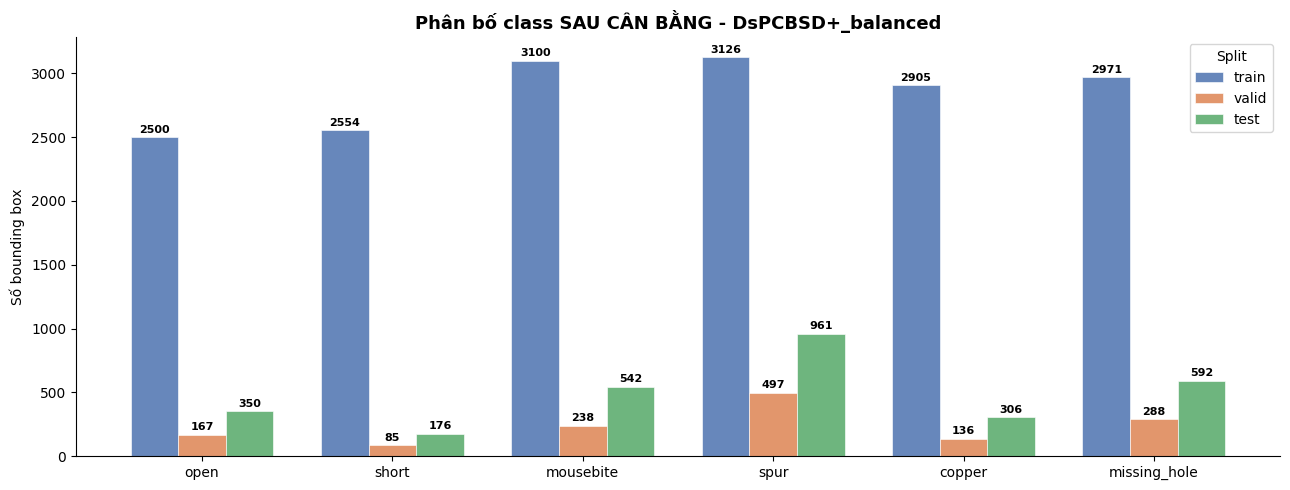

In [14]:
balanced_stats = count_class_distribution(OUTPUT_DIR)
plot_distribution(balanced_stats, title="Phân bố class SAU CÂN BẰNG - DsPCBSD+_balanced")

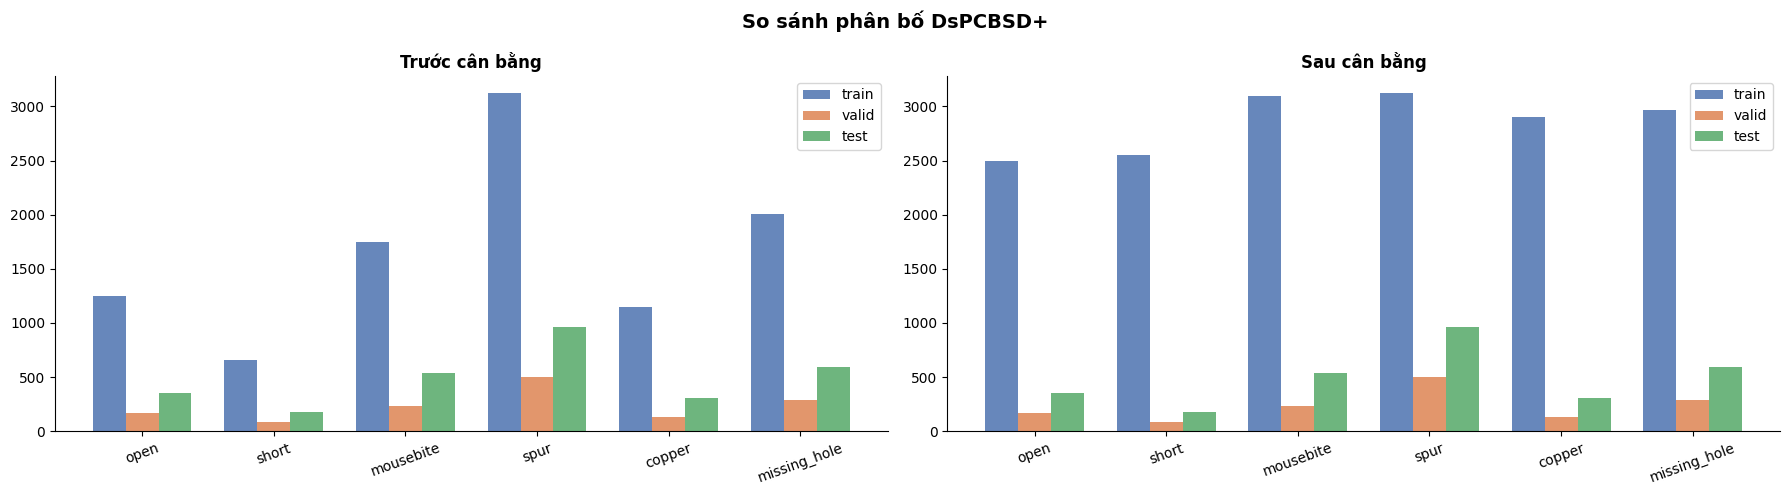

In [15]:
# So sánh trước / sau
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
x = np.arange(NUM_CLASSES)

for ax, stats, title in [
    (axes[0], original_stats,  "Trước cân bằng"),
    (axes[1], balanced_stats,  "Sau cân bằng"),
]:
    width = 0.25
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    for i, split in enumerate(SPLITS):
        vals = [stats[split].get(c, 0) for c in range(NUM_CLASSES)]
        ax.bar(x + i * width - width, vals, width,
               label=split, color=colors[i], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=20)
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("So sánh phân bố DsPCBSD+", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Visualize mẫu augmented

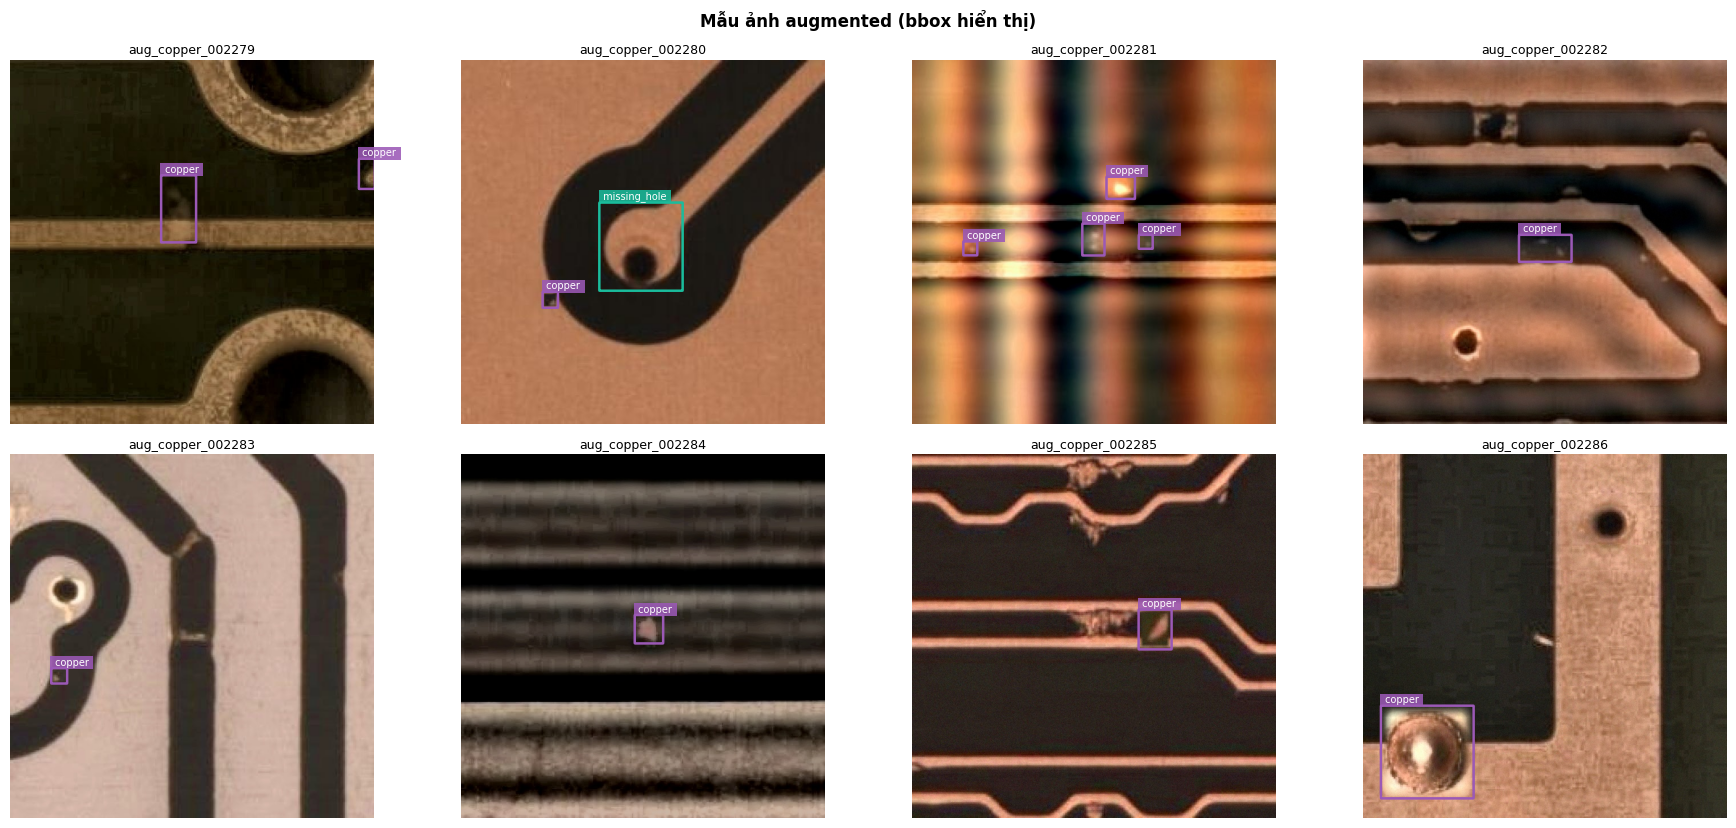

In [16]:
import matplotlib.patches as mpatches

DEFECT_COLORS = {
    "open":         "#E74C3C",   # đỏ
    "short":        "#3498DB",   # xanh dương
    "mousebite":    "#2ECC71",   # xanh lá
    "spur":         "#F39C12",   # cam
    "copper":       "#9B59B6",   # tím
    "missing_hole": "#1ABC9C",   # ngọc
    "unknown":      "#95A5A6",   # xám
}

def draw_yolo_boxes(ax, image_rgb: np.ndarray, boxes: list, title: str = ""):
    """
    Vẽ YOLO bounding boxes lên matplotlib Axes.

    Parameters
    ----------
    ax        : matplotlib Axes
    image_rgb : np.ndarray ở định dạng RGB (H, W, 3)
    boxes     : list of [cls_id, cx, cy, bw, bh]  (normalized)
    title     : tiêu đề subplot
    """
    ax.imshow(image_rgb)
    ax.set_title(title, fontsize=9, pad=4)
    ax.axis("off")

    h, w = image_rgb.shape[:2]

    for b in boxes:
        cls_id = int(b[0])
        cx, cy, bw_n, bh_n = b[1], b[2], b[3], b[4]
        label  = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"id:{cls_id}"
        color  = DEFECT_COLORS.get(label, DEFECT_COLORS["unknown"])

        x1    = (cx - bw_n / 2) * w
        y1    = (cy - bh_n / 2) * h
        bw_px = bw_n * w
        bh_px = bh_n * h

        rect = mpatches.FancyBboxPatch(
            (x1, y1), bw_px, bh_px,
            boxstyle="round,pad=1",
            linewidth=1.8,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(0, y1 - 2),
            f" {label} ",
            fontsize=7, color="white",
            va="bottom", ha="left",
            bbox=dict(facecolor=color, edgecolor="none", alpha=0.88, pad=1.0),
        )


def show_augmented_samples(output_dir: Path, n_samples: int = 8):
    aug_imgs = sorted((output_dir / "images" / "train").glob("aug_*.jpg"))[:n_samples]
    if not aug_imgs:
        print("Không tìm thấy ảnh aug_* trong output")
        return

    cols = 4
    rows = (len(aug_imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4.2))
    axes = np.array(axes).flatten()

    for ax, img_path in zip(axes, aug_imgs):
        lbl_path = output_dir / "labels" / "train" / (img_path.stem + ".txt")
        img, boxes = load_sample(img_path, lbl_path)
        if img is None:
            ax.axis("off")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        draw_yolo_boxes(ax, img_rgb, boxes, title=img_path.stem[:30])

    for ax in axes[len(aug_imgs):]:
        ax.axis("off")

    plt.suptitle("Mẫu ảnh augmented (bbox hiển thị)", fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()


show_augmented_samples(OUTPUT_DIR, n_samples=8)


## 11. Kiểm tra tính toàn vẹn label

In [17]:
def verify_dataset(root: Path, split: str = "train"):
    """Kiểm tra: mỗi ảnh có label, bbox nằm trong [0,1], không có NaN."""
    errors = []
    img_dir, lbl_dir = resolve_split_dirs(root, split)

    total = 0
    for img_p in img_dir.glob("*.*"):
        if img_p.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        total += 1
        lbl_p = lbl_dir / (img_p.stem + ".txt")

        if not lbl_p.exists():
            errors.append(f"Thiếu label: {img_p.name}")
            continue

        boxes = read_labels(lbl_p)
        for i, b in enumerate(boxes):
            cls, cx, cy, bw, bh = b
            if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
                errors.append(f"{lbl_p.name} box[{i}] ngoài biên: {b}")
            if cls < 0 or cls >= NUM_CLASSES:
                errors.append(f"{lbl_p.name} box[{i}] class_id không hợp lệ: {cls}")

    print(f"\nVerification [{split}]: {total} ảnh")
    if errors:
        print(f"  {len(errors)} lỗi:")
        for e in errors[:20]:
            print(f"     {e}")
    else:
        print("  Tất cả label hợp lệ!")

verify_dataset(OUTPUT_DIR, "train")
verify_dataset(OUTPUT_DIR, "valid")
verify_dataset(OUTPUT_DIR, "test")


Verification [train]: 8476 ảnh
  Tất cả label hợp lệ!

Verification [valid]: 718 ảnh
  Tất cả label hợp lệ!

Verification [test]: 1448 ảnh
  Tất cả label hợp lệ!


## 12. Tóm tắt kết quả

In [18]:
print("\n" + "="*55)
print("TÓM TẮT KẾT QUẢ CÂN BẰNG DỮ LIỆU")
print("="*55)

orig  = original_stats["train"]
final = balanced_stats["train"]

print(f"{'Class':>15}  {'Trước':>8}  {'Sau':>8}  {'Tăng':>8}  {'Tỷ lệ':>8}")
print("-" * 55)
for c, name in enumerate(CLASS_NAMES):
    before = orig.get(c, 0)
    after  = final.get(c, 0)
    diff   = after - before
    ratio  = after / before if before > 0 else float("inf")
    print(f"{name:>15}  {before:>8}  {after:>8}  +{diff:>7}  {ratio:>7.2f}x")

print("-" * 55)


TÓM TẮT KẾT QUẢ CÂN BẰNG DỮ LIỆU
          Class     Trước       Sau      Tăng     Tỷ lệ
-------------------------------------------------------
           open      1253      2500  +   1247     2.00x
          short       654      2554  +   1900     3.91x
      mousebite      1749      3100  +   1351     1.77x
           spur      3126      3126  +      0     1.00x
         copper      1151      2905  +   1754     2.52x
   missing_hole      2003      2971  +    968     1.48x
-------------------------------------------------------
